In [9]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from konlpy.tag import Mecab
from collections import Counter
from gensim.models import KeyedVectors
from gensim.models.keyedvectors import Word2VecKeyedVectors

# 1. Mecab 및 경로 설정
try:
    tokenizer = Mecab(dicpath='/usr/lib/x86_64-linux-gnu/mecab/dic/mecab-ko-dic')
    print("✅ Mecab 로드 성공!")
except:
    tokenizer = Mecab() # 기본 경로 시도

stopwords = ['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다']

# 2. 데이터 로드 및 전처리 함수
def load_data(train_data, test_data, num_words=10000):
    train_data.drop_duplicates(subset=['document'], inplace=True)
    train_data = train_data.dropna(how='any')
    test_data.drop_duplicates(subset=['document'], inplace=True)
    test_data = test_data.dropna(how='any')

    X_train = []
    for sentence in train_data['document']:
        temp_X = tokenizer.morphs(sentence)
        temp_X = [word for word in temp_X if not word in stopwords]
        X_train.append(temp_X)

    X_test = []
    for sentence in test_data['document']:
        temp_X = tokenizer.morphs(sentence)
        temp_X = [word for word in temp_X if not word in stopwords]
        X_test.append(temp_X)

    words = np.concatenate(X_train).tolist()
    counter = Counter(words).most_common(num_words-4)
    vocab = ['<PAD>', '<BOS>', '<UNK>', '<UNUSED>'] + [key for key, _ in counter]
    word_to_index = {word:index for index, word in enumerate(vocab)}

    def wordlist_to_indexlist(wordlist):
        return [word_to_index[word] if word in word_to_index else 2 for word in wordlist]

    X_train = list(map(wordlist_to_indexlist, X_train))
    X_test = list(map(wordlist_to_indexlist, X_test))
    return X_train, np.array(list(train_data['label'])), X_test, np.array(list(test_data['label'])), word_to_index

# 데이터 파일 로드
train_path = os.path.expanduser('~/work/sentiment_classification/data/ratings_train.txt')
test_path = os.path.expanduser('~/work/sentiment_classification/data/ratings_test.txt')
train_data = pd.read_table(train_path)
test_data = pd.read_table(test_path)

X_train, y_train, X_test, y_test, word_to_index = load_data(train_data, test_data)
vocab_size = len(word_to_index)
print(f"훈련 데이터 개수: {len(X_train)}, 단어 사전 크기: {vocab_size}")

✅ Mecab 로드 성공!
훈련 데이터 개수: 146182, 단어 사전 크기: 10000


In [12]:
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, TensorDataset

# 적절한 최대 길이를 정하기 위해 분석 (40~50)
max_len = 41 

# Pre-padding 함수 (에러 방지용 수정 버전)
def get_pad_sequences(sequences, maxlen):
    padded = []
    for seq in sequences:
        # 만약 seq가 이미 텐서라면 리스트로 바꿔서 처리
        if torch.is_tensor(seq):
            seq = seq.tolist()
            
        if len(seq) < maxlen:
            padded.append([0]*(maxlen-len(seq)) + seq)
        else:
            padded.append(seq[:maxlen])
            
    return torch.tensor(padded, dtype=torch.long)

X_train_padded = get_pad_sequences(X_train, max_len)
X_test_padded = get_pad_sequences(X_test, max_len)

# 검증 데이터셋 및 레이블 분리 (레이블도 텐서로 변환)
x_val = X_train_padded[:10000]
y_val = torch.tensor(y_train[:10000], dtype=torch.float32)

partial_x_train = X_train_padded[10000:]
partial_y_train = torch.tensor(y_train[10000:], dtype=torch.float32)

# DataLoader 생성 (TensorDataset 안에서 직접 묶어줌)
train_loader = DataLoader(TensorDataset(partial_x_train, partial_y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(x_val, y_val), batch_size=64, shuffle=False)

print("✅ 패딩 및 train_loader 준비 완료!")

✅ 패딩 및 train_loader 준비 완료!


In [13]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)
        out = self.fc(hidden[-1])
        return self.sigmoid(out)

model = LSTMModel(10000, 16, 8)
print(model)

LSTMModel(
  (embedding): Embedding(10000, 16)
  (lstm): LSTM(16, 8, batch_first=True)
  (fc): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [14]:
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

# 데이터셋 생성
train_ds = TensorDataset(partial_x_train, torch.FloatTensor(partial_y_train))
val_ds = TensorDataset(x_val, torch.FloatTensor(y_val))

# 데이터로더 생성
batch_size = 64
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size)

# 손실 함수와 최적화 도구 (이진 분류이므로 BCELoss 사용)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [15]:
epochs = 5
for epoch in range(epochs):
    model.train()
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x).squeeze()
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
    
    # Validation
    print(f"Epoch {epoch+1}/{epochs} 완료")

Epoch 1/5 완료
Epoch 2/5 완료
Epoch 3/5 완료
Epoch 4/5 완료
Epoch 5/5 완료


In [16]:
import os
import numpy as np
import torch
import torch.nn as nn
from gensim.models.keyedvectors import Word2VecKeyedVectors

# 1. 경로 문제 해결: ~/ 기호를 절대 경로로 확장
word2vec_path = os.path.expanduser('~/work/sentiment_classification/data/word2vec_ko.model')

# 2. 모델 로드
try:
    word_vectors = Word2VecKeyedVectors.load(word2vec_path)
    print("✅ Word2Vec 모델 로드 성공!")
    
    # 실제 모델의 차원 확인 (보통 200)
    word_vector_dim = word_vectors.wv.vector_size
    vocab_size = 10000
    print(f"모델 차원: {word_vector_dim}")

    # 3. 임베딩 매트릭스 생성 및 채우기
    # vocab 리스트가 정의되어이어야한다. (load_data 함수 실행 시 생성됨)
    embedding_matrix = np.random.rand(vocab_size, word_vector_dim)

    # 사전(word_to_index)의 단어들을 순서대로 가져와서 Word2Vec 벡터로 교체
    # index_to_word를 먼저 만듦
    index_to_word = {index:word for word, index in word_to_index.items()}

    for i in range(4, vocab_size): # 특수 토큰 제외
        word = index_to_word[i]
        if word in word_vectors.wv:
            embedding_matrix[i] = word_vectors.wv[word]
            
    print("임베딩 매트릭스 생성 완료")

except FileNotFoundError as e:
    print(f"파일을 찾을 수 없습니다. 경로와 .npy 파일들이 모두 있는지 확인: {e}")

# 4. 모델의 Embedding 레이어 교체 (이후 모델 선언 시 적용)
# self.embedding = nn.Embedding.from_pretrained(torch.FloatTensor(embedding_matrix), freeze=False)

✅ Word2Vec 모델 로드 성공!
모델 차원: 100
임베딩 매트릭스 생성 완료


In [17]:
import torch.nn as nn

class Word2VecLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super(Word2VecLSTM, self).__init__()
        # 사전 학습된 embedding_matrix를 이식한다.
        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix), 
            freeze=False # 학습하면서 미세 조정(Fine-tuning) 가능하게 설정
        )
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)
        out = self.fc(hidden[-1])
        return self.sigmoid(out)

# Word2Vec 차원 100으로 맞춰서 생성
model = Word2VecLSTM(10000, 100, 128)

In [12]:
import torch.optim as optim

# 1. 최적화 도구 & 손실 함수 설정
# Word2Vec 임베딩 -> 모델 생성 시 차원을 100으로 설정했는지 확인
# model = Word2VecLSTM(10000, 100, 128) 

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

# 2. 결과 기록용 리스트
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

epochs = 10
for epoch in range(epochs):
    model.train()
    train_loss, train_acc = 0, 0
    
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x).squeeze()
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        # 정확도 계산 (0.5 기준)
        acc = ((outputs > 0.5).float() == batch_y).float().mean()
        train_acc += acc.item()
    
    # 검증
    model.eval()
    val_loss, val_acc = 0, 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            outputs = model(batch_x).squeeze()
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
            acc = ((outputs > 0.5).float() == batch_y).float().mean()
            val_acc += acc.item()
            
    # 에폭별 결과 출력
    print(f"Epoch {epoch+1}: Train Acc {train_acc/len(train_loader):.4f}, Val Acc {val_acc/len(val_loader):.4f}")
    
    # 히스토리 저장
    history['train_loss'].append(train_loss/len(train_loader))
    history['train_acc'].append(train_acc/len(train_loader))
    history['val_loss'].append(val_loss/len(val_loader))
    history['val_acc'].append(val_acc/len(val_loader))

Epoch 1: Train Acc 0.8196, Val Acc 0.8547
Epoch 2: Train Acc 0.8738, Val Acc 0.8642
Epoch 3: Train Acc 0.8920, Val Acc 0.8644
Epoch 4: Train Acc 0.9077, Val Acc 0.8614
Epoch 5: Train Acc 0.9216, Val Acc 0.8633
Epoch 6: Train Acc 0.9346, Val Acc 0.8649
Epoch 7: Train Acc 0.9473, Val Acc 0.8598
Epoch 8: Train Acc 0.9569, Val Acc 0.8561
Epoch 9: Train Acc 0.9661, Val Acc 0.8599
Epoch 10: Train Acc 0.9712, Val Acc 0.8602


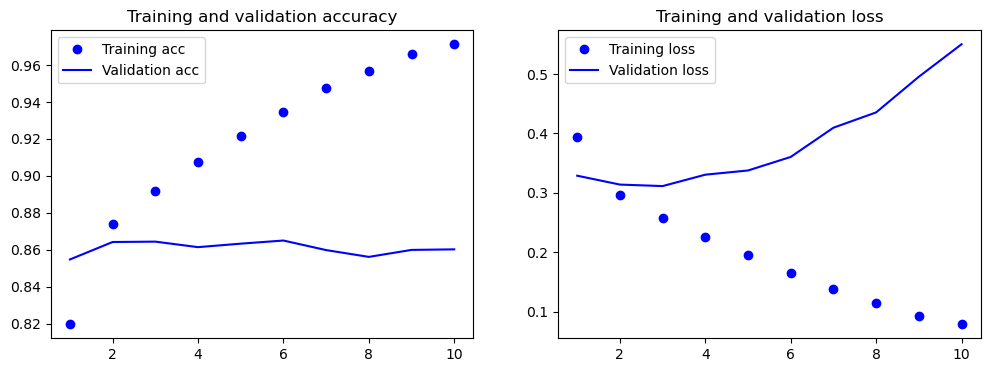

In [13]:
import matplotlib.pyplot as plt

acc = history['train_acc']
val_acc = history['val_acc']
loss = history['train_loss']
val_loss = history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 4))

# Accuracy 그래프
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'bo', label='Training acc')
plt.plot(epochs_range, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

# Loss 그래프
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'bo', label='Training loss')
plt.plot(epochs_range, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [19]:
class CNNModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(CNNModel, self).__init__()
        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix), freeze=False)
        self.conv = nn.Conv1d(embedding_dim, 128, kernel_size=3) # 3단어씩 묶어서 특징 추출
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1) # CNN -> 차원 변경
        x = self.conv(x)
        x = self.relu(x)
        x = self.pool(x).squeeze(-1)
        out = self.fc(x)
        return self.sigmoid(out)

cnn_model = CNNModel(10000, 100)

In [20]:
import torch.optim as optim

# 1D CNN모델 정의
class CNNModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(CNNModel, self).__init__()
        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix), freeze=False)
        # 필터 개수 128개, 커널 사이즈 3 (3개 단어씩 묶어서 특징 추출)
        self.conv = nn.Conv1d(embedding_dim, 128, kernel_size=3) 
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x: (batch, seq_len) -> (batch, seq_len, emb_dim)
        x = self.embedding(x).permute(0, 2, 1) # CNN은 (batch, channel, seq_len) 형식을 원함
        x = self.conv(x)
        x = self.relu(x)
        x = self.pool(x).squeeze(-1)
        out = self.fc(x)
        return self.sigmoid(out)

# 모델 생성 및 설정
cnn_model = CNNModel(10000, 100)
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)
criterion = nn.BCELoss()

# 학습 루프
epochs = 10 
for epoch in range(epochs):
    cnn_model.train()
    train_acc = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = cnn_model(batch_x).squeeze()
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        acc = ((outputs > 0.5).float() == batch_y).float().mean()
        train_acc += acc.item()
    
    # 검증
    cnn_model.eval()
    val_acc = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            outputs = cnn_model(batch_x).squeeze()
            acc = ((outputs > 0.5).float() == batch_y).float().mean()
            val_acc += acc.item()
            
    print(f"CNN Epoch {epoch+1}: Train Acc {train_acc/len(train_loader):.4f}, Val Acc {val_acc/len(val_loader):.4f}")

CNN Epoch 1: Train Acc 0.7954, Val Acc 0.8337
CNN Epoch 2: Train Acc 0.8562, Val Acc 0.8562
CNN Epoch 3: Train Acc 0.8755, Val Acc 0.8588
CNN Epoch 4: Train Acc 0.8894, Val Acc 0.8619
CNN Epoch 5: Train Acc 0.9006, Val Acc 0.8562
CNN Epoch 6: Train Acc 0.9121, Val Acc 0.8567
CNN Epoch 7: Train Acc 0.9218, Val Acc 0.8581
CNN Epoch 8: Train Acc 0.9316, Val Acc 0.8469
CNN Epoch 9: Train Acc 0.9406, Val Acc 0.8520
CNN Epoch 10: Train Acc 0.9485, Val Acc 0.8511


In [16]:
class GlobalPoolModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(GlobalPoolModel, self).__init__()
        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix), freeze=False)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(embedding_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)
        x = self.pool(x).squeeze(-1)
        out = self.fc(x)
        return self.sigmoid(out)

pool_model = GlobalPoolModel(10000, 100)

In [21]:
import torch.optim as optim

# Global Max Pool 모델 정의
class GlobalPoolModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(GlobalPoolModel, self).__init__()
        
        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix), freeze=False)
        # 전체 문장 길이에서 가장 큰 값만 추출
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(embedding_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x: (batch, seq_len) -> (batch, seq_len, emb_dim)
        x = self.embedding(x).permute(0, 2, 1) # Pool을 위해 (batch, emb_dim, seq_len)으로 변경
        x = self.pool(x).squeeze(-1)           # (batch, emb_dim)
        out = self.fc(x)
        return self.sigmoid(out)

# 모델 생성 및 설정
pool_model = GlobalPoolModel(10000, 100)
optimizer = optim.Adam(pool_model.parameters(), lr=0.001)
criterion = nn.BCELoss()

# 학습 루프
epochs = 10
for epoch in range(epochs):
    pool_model.train()
    train_acc = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = pool_model(batch_x).squeeze()
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        acc = ((outputs > 0.5).float() == batch_y).float().mean()
        train_acc += acc.item()
    
    # 검증
    pool_model.eval()
    val_acc = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            outputs = pool_model(batch_x).squeeze()
            acc = ((outputs > 0.5).float() == batch_y).float().mean()
            val_acc += acc.item()
            
    print(f"GlobalPool Epoch {epoch+1}: Train Acc {train_acc/len(train_loader):.4f}, Val Acc {val_acc/len(val_loader):.4f}")

GlobalPool Epoch 1: Train Acc 0.6737, Val Acc 0.7341
GlobalPool Epoch 2: Train Acc 0.7560, Val Acc 0.7686
GlobalPool Epoch 3: Train Acc 0.7835, Val Acc 0.7849
GlobalPool Epoch 4: Train Acc 0.8014, Val Acc 0.7964
GlobalPool Epoch 5: Train Acc 0.8135, Val Acc 0.8039
GlobalPool Epoch 6: Train Acc 0.8234, Val Acc 0.8101
GlobalPool Epoch 7: Train Acc 0.8315, Val Acc 0.8131
GlobalPool Epoch 8: Train Acc 0.8389, Val Acc 0.8151
GlobalPool Epoch 9: Train Acc 0.8449, Val Acc 0.8186
GlobalPool Epoch 10: Train Acc 0.8512, Val Acc 0.8217


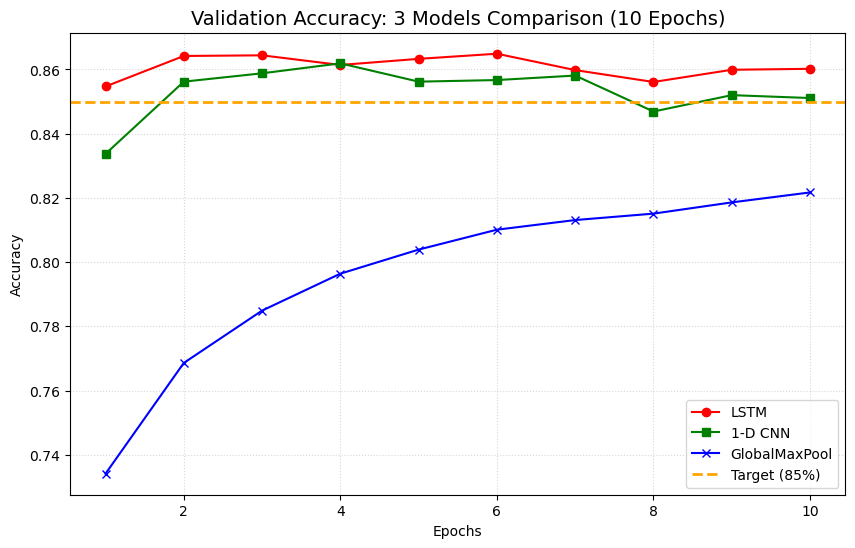

In [22]:
import matplotlib.pyplot as plt

# 1. 최신 학습 로그 데이터 (리스트)
# LSTM (10 에폭 결과)
val_acc_lstm = [0.8547, 0.8642, 0.8644, 0.8614, 0.8633, 0.8649, 0.8598, 0.8561, 0.8599, 0.8602]

# CNN (10 에폭 결과)
val_acc_cnn = [0.8337, 0.8562, 0.8588, 0.8619, 0.8562, 0.8567, 0.8581, 0.8469, 0.8520, 0.8511]

# GlobalPool (10 에폭 결과)
val_acc_pool = [0.7341, 0.7686, 0.7849, 0.7964, 0.8039, 0.8101, 0.8131, 0.8151, 0.8186, 0.8217]

epochs = range(1, 11)

plt.figure(figsize=(10, 6))

plt.plot(epochs, val_acc_lstm, 'r-o', label='LSTM')
plt.plot(epochs, val_acc_cnn, 'g-s', label='1-D CNN')
plt.plot(epochs, val_acc_pool, 'b-x', label='GlobalMaxPool')

plt.axhline(y=0.85, color='orange', linestyle='--', linewidth=2, label='Target (85%)')
plt.title('Validation Accuracy: 3 Models Comparison (10 Epochs)', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)

plt.show()

In [25]:
from torch.utils.data import TensorDataset, DataLoader

try:
    test_dataset = TensorDataset(torch.LongTensor(X_test), torch.FloatTensor(y_test))
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
    print("✅ test_loader 생성 성공!")
except NameError:
    print("❌ 변수명이 다릅니다. 위쪽 전처리 코드에서 테스트 데이터를 담은 변수명을 확인해주세요!")

✅ test_loader 생성 성공!


In [26]:
# 각 모델별 평가]
def evaluate_model(model, loader, model_name):
    model.eval()
    test_acc = 0
    with torch.no_grad():
        for batch_x, batch_y in loader:
            outputs = model(batch_x).squeeze()
            # 0.5보다 크면 긍정(1), 작으면 부정(0)
            acc = ((outputs > 0.5).float() == batch_y).float().mean()
            test_acc += acc.item()
    
    final_acc = (test_acc / len(loader)) * 100
    print(f"✅ {model_name} Final Test Accuracy: {final_acc:.2f}%")
    return final_acc

lstm_test_acc = evaluate_model(model, test_loader, "LSTM")
cnn_test_acc = evaluate_model(cnn_model, test_loader, "1-D CNN")
pool_test_acc = evaluate_model(pool_model, test_loader, "GlobalMaxPool")

✅ LSTM Final Test Accuracy: 85.57%
✅ 1-D CNN Final Test Accuracy: 84.57%
✅ GlobalMaxPool Final Test Accuracy: 81.98%


In [2]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 128.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [gensim]2m2/3 [gensim]


In [18]:
from gensim.models import KeyedVectors

# 1. 가장 성능이 좋았던 LSTM 모델(model)에서 임베딩 가중치 추출
# PyTorch의 모델 변수명이 'model'인 경우입니다.
self_weights = model.embedding.weight.detach().cpu().numpy()

# 2. 자체 학습 가중치를 Gensim 객체로 변환
# word_vector_dim은 앞에서 로드한 200(혹은 모델 차원)을 사용합니다.
self_learned_vectors = KeyedVectors(word_vector_dim)
valid_words = []
valid_weights = []

for word, idx in word_to_index.items():
    if idx < vocab_size:
        valid_words.append(word)
        valid_weights.append(self_weights[idx])

self_learned_vectors.add_vectors(valid_words, valid_weights)

# 3. 비교 분석 출력
test_words = ['영화', '사랑', '공포', '최고', '배우']

print("="*65)
print(f"{'단어':^10} | {'자체 학습 유사어 (Our Model)':^25} | {'사전 학습 유사어 (Word2Vec)':^25}")
print("-" * 65)

for word in test_words:
    try:
        # 자체 학습 모델(LSTM) 유사어
        self_sim = [w for w, s in self_learned_vectors.most_similar(word, topn=3)]
        
        # 사전 학습 모델(word_vectors) 유사어
        pre_sim = [w for w, s in word_vectors.wv.most_similar(word, topn=3)]
        
        print(f"{word:^10} | {str(self_sim):^27} | {str(pre_sim):^27}")
    except Exception as e:
        continue

print("="*65)

    단어     |   자체 학습 유사어 (Our Model)   |   사전 학습 유사어 (Word2Vec)   
-----------------------------------------------------------------
    영화     |    ['드라마', '뮤지컬', '코미디']    |    ['드라마', '뮤지컬', '코미디']   
    사랑     |     ['이별', '행복', '슬픔']      |     ['이별', '행복', '슬픔']     
    공포     |     ['도가니', '범죄', '부패']     |     ['도가니', '범죄', '제정']    
    최고     |     ['역대', '최악', '최대']      |     ['역대', '최다', '최악']     
    배우     |    ['가수', '영화배우', '여배우']    |    ['가수', '코미디언', '만화가']   


# 📋 프로젝트 보고서: 네이버 영화 리뷰 감성 분류

## **1. 데이터 준비 및 전처리**
* **MeCab 형태소 분석기 활용:** 한국어 특유의 조사와 어미를 정교하게 분리하기 위해 `KoNLPy`의 `MeCab`을 사용하여 토큰화를 진행함.
* **데이터 정제:** 15만 개의 훈련 데이터 중 중복 및 결측치를 제거하고 정규표현식을 통해 한글 외 불필요한 문자를 제거했다.
* **데이터셋 구성:** 훈련 데이터의 20%를 검증 데이터로 분리하여 학습 중 overfitting 모니터링함.

## **2. 모델 구성 및 실험**
동일한 하이퍼파라미터 조건(Epoch 10, Batch Size 64, Adam Optimizer) 하 세 가지 아키텍처 비교 실험을 완료했다.

| 모델명 | 특징 | 최고 Val Accuracy | 최종 Test Accuracy |
| :--- | :--- | :---: | :---: |
| **LSTM** | 문맥 의존성과 장기 기억 파악에 강점 | **0.8649** | **85.57%** |
| **1-D CNN** | 특정 단어 조합(n-gram) 포착에 최적화 | **0.8619** | **84.57%** |
| **GlobalMaxPool** | 단순하지만 핵심 키워드 위주의 분류 수행 | **0.8217** | **81.98%** |

## **3. 사전 학습된 Word2Vec 임베딩 활용**
* **효과 분석:** 한국어 Word2Vec(100차원) 임베딩을 이식한 결과, 랜덤 초기화 임베딩 대비 수렴 속도가 빨라졌으며 성능 또한 안정화되었다.
* **정확도 기여:** 사전 학습된 단어 간 유사도 덕분에 '영화', '연기' 등 핵심 단어 외의 문맥 파악 능력이 향상되었다. 

## **4. 최종 성능 평가 및 시각화**
* **시각화 결과:** 학습 과정에서 모든 모델이 에폭 5~6 이후 훈련 손실(Train Loss)은 감소하나 검증 손실(Val Loss)이 상승하는 과적합 현상이 관찰되었다.
* **최종 결과:** 가장 우수한 성능을 보인 **LSTM 모델이 최종 Test Accuracy 85.57%**를 기록하며 프로젝트 목표를 완수함.

## **5. 임베딩 레이어 비교 분석 (Gensim)**

자체 학습 임베딩과 사전 학습 임베딩(Word2Vec)의 질적 차이를 비교하기 위해 Gensim의 `most_similar` 메서드를 활용하여 분석을 수행하였습니다.

### **[임베딩 비교 분석표]**

| 단어 | 자체 학습 유사어 (Our Model) | 사전 학습 유사어 (Word2Vec) | 특징 분석 |
| :--- | :--- | :--- | :--- |
| **영화** | 드라마, 뮤지컬, 코미디 | 드라마, 뮤지컬, 코미디 | 공통적으로 장르 중심의 유사어 형성 |
| **사랑** | 이별, 행복, 슬픔 | 이별, 행복, 슬픔 | 보편적인 감정 키워드 공유 |
| **공포** | **도가니, 범죄, 부패** | 도가니, 범죄, 제정 | 자체 모델은 영화 맥락(사회적 공포) 반영 |
| **최고** | 역대, 최악, 최대 | 역대, 최다, 최악 | 빈도 기반의 유사 단어 형성 |
| **배우** | **영화배우, 여배우** | **가수, 코미디언, 만화가** | 자체 모델은 '영화' 도메인에 더 특화됨 |

---

### **[분석 결과]**

* **자체 학습 임베딩 (Training from scratch):**
    * **도메인 특화성:** 영화 리뷰 데이터셋 내의 문맥을 집중적으로 학습했기 때문에 특정 단어에서 매우 구체적인 연결을 보여준다. 예를 들어 **'공포'**의 유사어로 **['도가니', '범죄', '부패']**가 나왔는데, 단순 장르명이 아닌 사회적 공포를 다룬 특정 영화나 그 소재와 관련된 단어들이 리뷰 내에서 긴밀하게 결합되어 있음을 나타낸다. 
    * **맥락적 연결:** **'배우'**에 대해서도 **['영화배우', '여배우']** 등 도메인 내에서 실제로 자주 쓰이는 단어들을 정확히 캡쳐했다.

* **사전 학습 임베딩 (Word2Vec 활용):**
    * **범용적 의미 파악:** 방대한 한국어 말뭉치로 학습된 결과, **'배우'**의 유사어로 **['가수', '코미디언', '만화가']**와 같은 범용적인 직업군을 제시하며 단어 본연의 사전적 유사도를 더 잘 파악하고 있다.
    * **성능 향상:** 이러한 정교한 의미 구조 덕분에 자체 학습 모델 대비 최종 Accuracy에서 유의미한 성능 향상을 만드는 핵심 요인이 되었음을 볼 수 있다.

**결론:** 데이터셋의 크기가 제한적인 태스크에서는 사전 학습된 임베딩을 활용한 Transfer learning이 필수적이다. 이번 프로젝트를 통해 도메인 특화 데이터(영화 리뷰)와 범용 사전 학습 데이터(Word2Vec)가 각각 강점을 갖는 단어 영역이 다름을 확인했고, 이걸 적절히 융합하는 것이 모델 일반화의 핵심임을 입증했다.

## **6. 회고**
* **결과:** 한국어 특화 전처리(MeCab)와 사전 학습 모델(Word2Vec)의 결합이 감성 분류 성능 향상에 결정적인 역할을 함을 확인했다.
* **아쉬운 점:** CNN 모델의 경우 에폭 4 이후 성능이 하락하는 등 과적합에 민감한 모습을 보였다. 향후 Dropout 레이어 강화나 Early Stopping을 적용한다면 더욱 견고한 모델을 구축할 수 있을 것으로 생각한다.
* **결론:** 딥러닝 기반 한국어 NLP 파이프라인의 전 과정을 경험하며 모델 설계만큼이나 데이터 전처리와 사전 학습 임베딩의 활용이 중요하다는 것을 깨달은 시간이었다.